In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from wordcloud import WordCloud
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings("ignore")
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to C:\Users\M.I.S
[nltk_data]     SITHLTD\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [66]:
df = pd.read_csv("netflix_titles.csv")

In [67]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [69]:
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [70]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [71]:
df['year_added'] = pd.to_datetime(df['date_added'],format='mixed').dt.year

In [72]:
df['lag_years'] = df['year_added'] - df['release_year']

In [73]:
df['lag_years']

0        1.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
8802    12.0
8803     1.0
8804    10.0
8805    14.0
8806     4.0
Name: lag_years, Length: 8807, dtype: float64

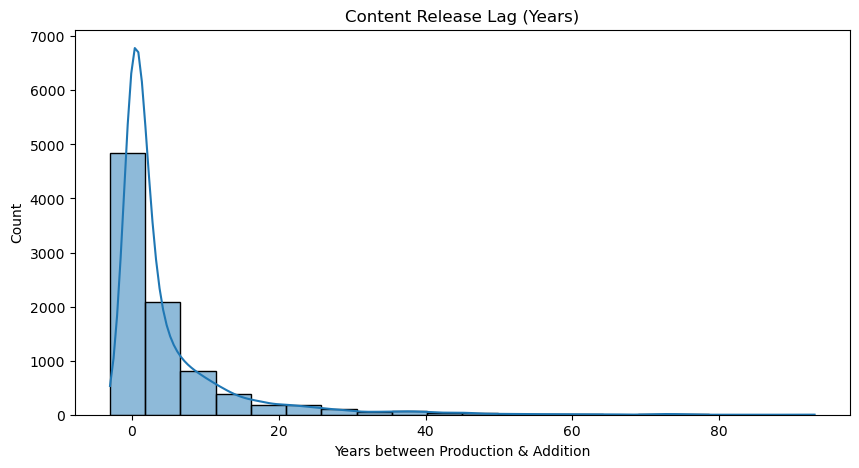

In [74]:
plt.figure(figsize=(10,5))
sns.histplot(df['lag_years'].dropna(), bins=20, kde=True)
plt.title("Content Release Lag (Years)")
plt.xlabel("Years between Production & Addition")
plt.show()

In [75]:
# === 2. Content Type Balance & Strategic Mix ===
df['duration'] = df['duration'].fillna("0 min")
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].apply(lambda x: 'Season' if 'Season' in x else 'Minutes')

In [ ]:
df['genres'] = df['listed_in'].str.split(', ')
genre_explode = df.explode('genres')
df['country'] = df['country'].fillna("Unknown")
country_explode = df.assign(country_split=df['country'].str.split(', ')).explode('country_split')

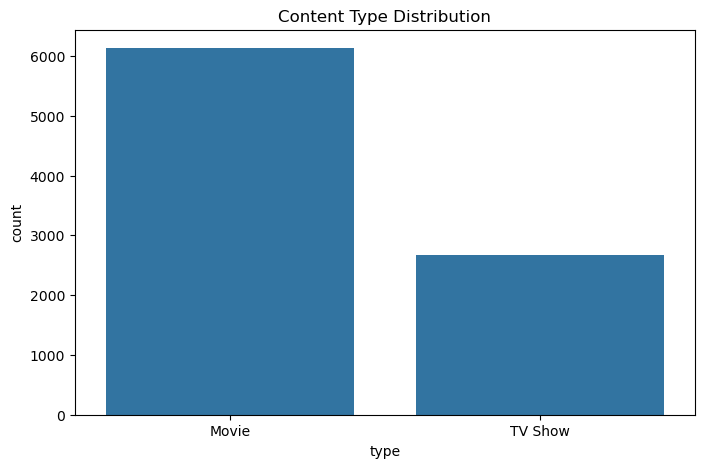

In [76]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title("Content Type Distribution")
plt.show()

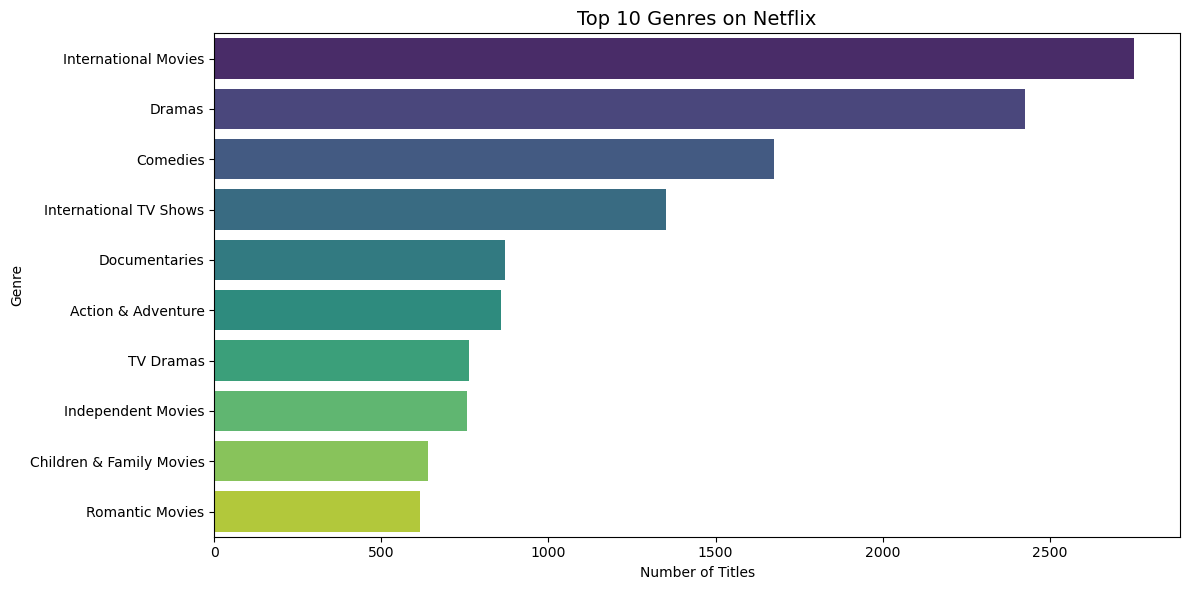

In [77]:
# Split 'listed_in' into a list of genres
df['genres'] = df['listed_in'].str.split(', ')

# Explode into multiple rows and reset index to avoid duplicate index issue
genre_explode = df.explode('genres').reset_index(drop=True)

# Drop NaN or empty genre values
genre_explode = genre_explode[genre_explode['genres'].notna() & (genre_explode['genres'] != '')]

# Plot top 10 genres
plt.figure(figsize=(12, 6))
sns.countplot(
    y='genres',
    data=genre_explode,
    order=genre_explode['genres'].value_counts().head(10).index,
    palette='viridis'
)
plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


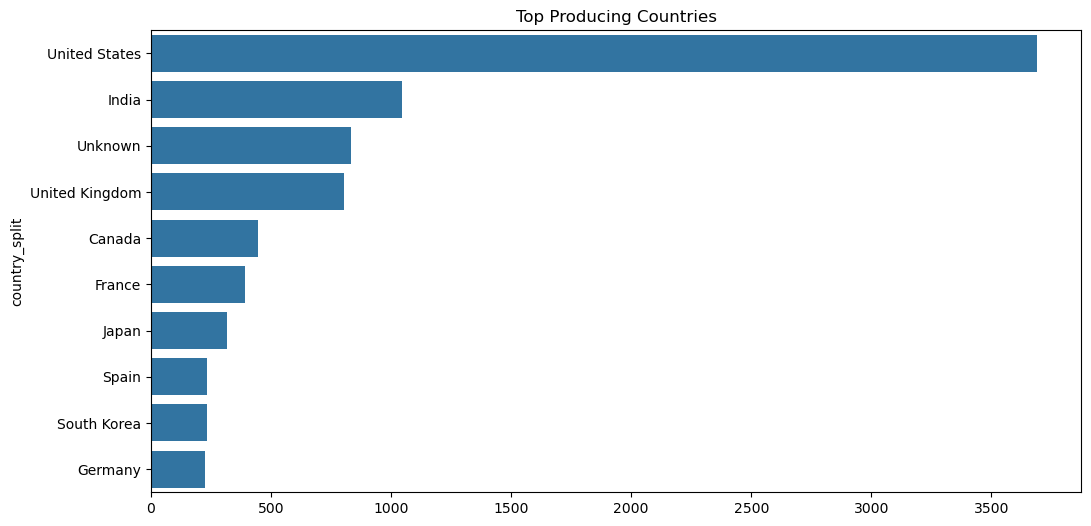

In [78]:
df['country'] = df['country'].fillna("Unknown")
country_explode = df.assign(country_split=df['country'].str.split(', ')).explode('country_split')

plt.figure(figsize=(12,6))
top_countries = country_explode['country_split'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top Producing Countries")
plt.show()

In [79]:
# df['director'] = df['director'].fillna("Unknown")
# df['cast'] = df['cast'].fillna("Unknown")
# df['cast_split'] = df['cast'].str.split(', ')
# cast_explode = df.explode('cast_split')

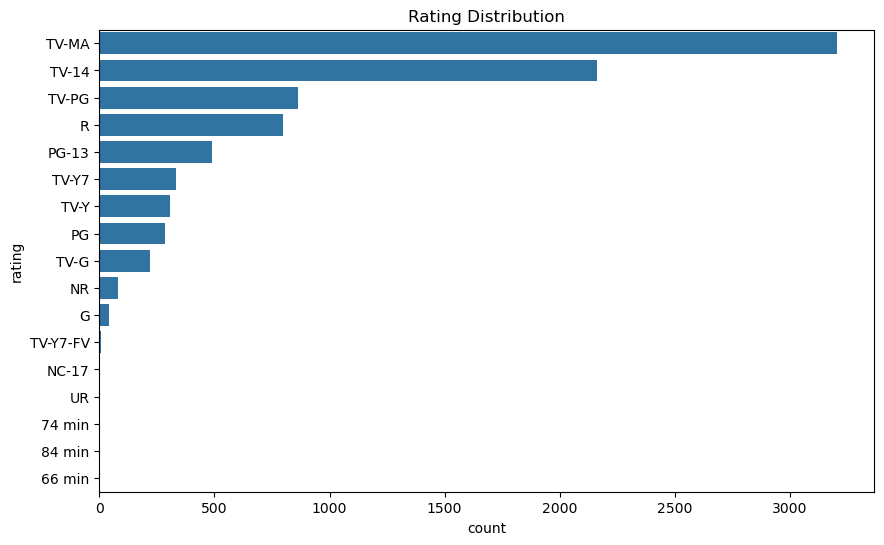

In [56]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()

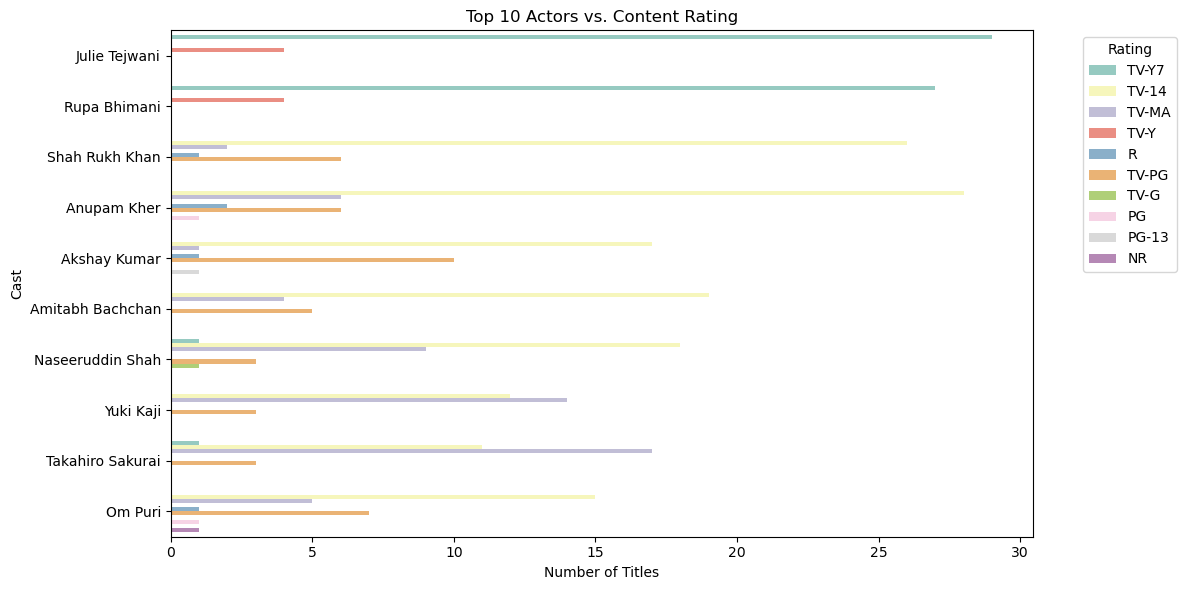

In [81]:
# Split cast into individual names and explode
df_cast = df[['cast', 'rating']].dropna()
df_cast['cast'] = df_cast['cast'].str.split(', ')
cast_exploded = df_cast.explode('cast').reset_index(drop=True)

# Get top 10 recurring cast members
top_cast = cast_exploded['cast'].value_counts().head(10).index

# Filter to top actors
filtered_cast = cast_exploded[cast_exploded['cast'].isin(top_cast)]

# Plot
plt.figure(figsize=(12,6))
sns.countplot(data=filtered_cast, y='cast', hue='rating', palette='Set3')
plt.title("Top 10 Actors vs. Content Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Cast")
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [82]:


# Drop missing values
df_clean = df.dropna(subset=['director', 'rating'])

# Split by type
df_movies = df_clean[df_clean['type'] == 'Movie']
df_shows = df_clean[df_clean['type'] == 'TV Show']

# Top 10 directors by type
top_movie_directors = df_movies['director'].value_counts().head(10).index
top_show_directors = df_shows['director'].value_counts().head(10).index

# Filter
movie_directors = df_movies[df_movies['director'].isin(top_movie_directors)]
show_directors = df_shows[df_shows['director'].isin(top_show_directors)]



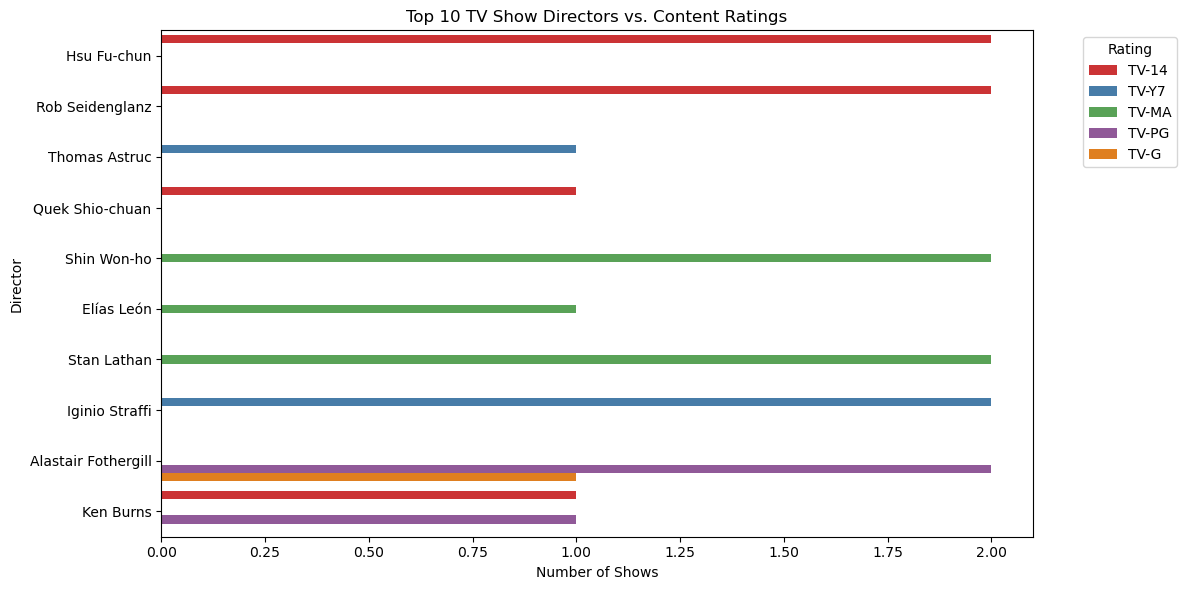

In [83]:
# --- Plot for TV Shows ---
plt.figure(figsize=(12, 6))
sns.countplot(data=show_directors, y='director', hue='rating', palette='Set1')
plt.title("Top 10 TV Show Directors vs. Content Ratings")
plt.xlabel("Number of Shows")
plt.ylabel("Director")
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

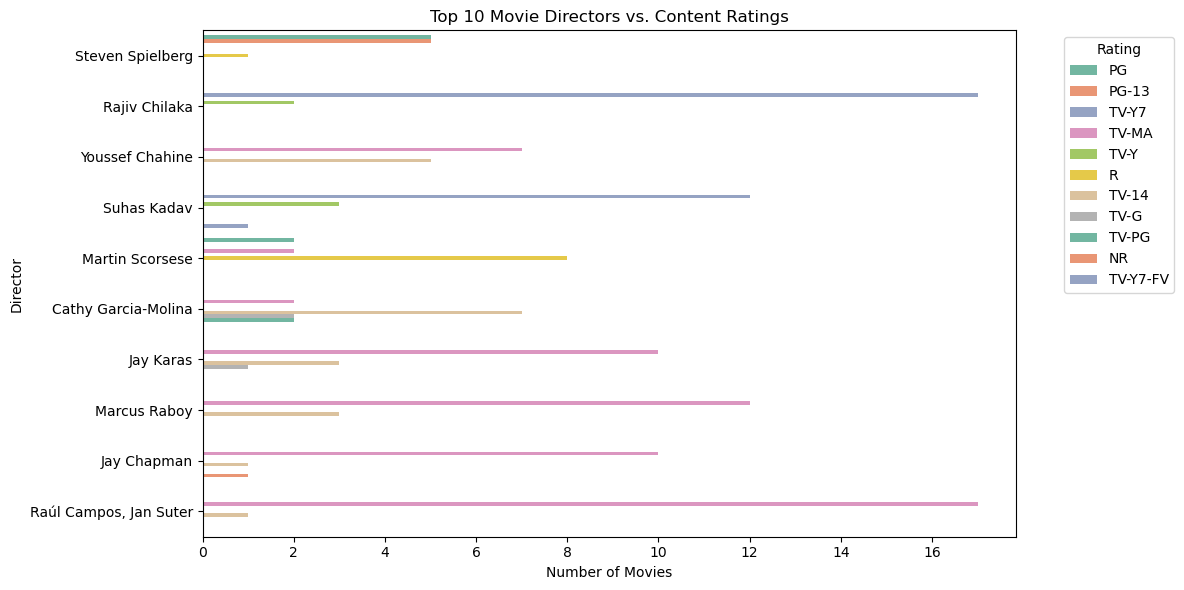

In [84]:
# --- Plot for Movies ---
plt.figure(figsize=(12, 6))
sns.countplot(data=movie_directors, y='director', hue='rating', palette='Set2')
plt.title("Top 10 Movie Directors vs. Content Ratings")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()




In [85]:
# Drop missing values
df_cast_clean = df.dropna(subset=['cast', 'rating'])

# Explode cast list
df_cast_clean['cast'] = df_cast_clean['cast'].str.split(', ')
cast_exploded = df_cast_clean.explode('cast')

# Separate by type
cast_movies = cast_exploded[cast_exploded['type'] == 'Movie']
cast_shows = cast_exploded[cast_exploded['type'] == 'TV Show']

# Get top 10 frequent cast for each
top_movie_cast = cast_movies['cast'].value_counts().head(10).index
top_show_cast = cast_shows['cast'].value_counts().head(10).index

# Filter to top actors
movie_cast_filtered = cast_movies[cast_movies['cast'].isin(top_movie_cast)]
show_cast_filtered = cast_shows[cast_shows['cast'].isin(top_show_cast)]



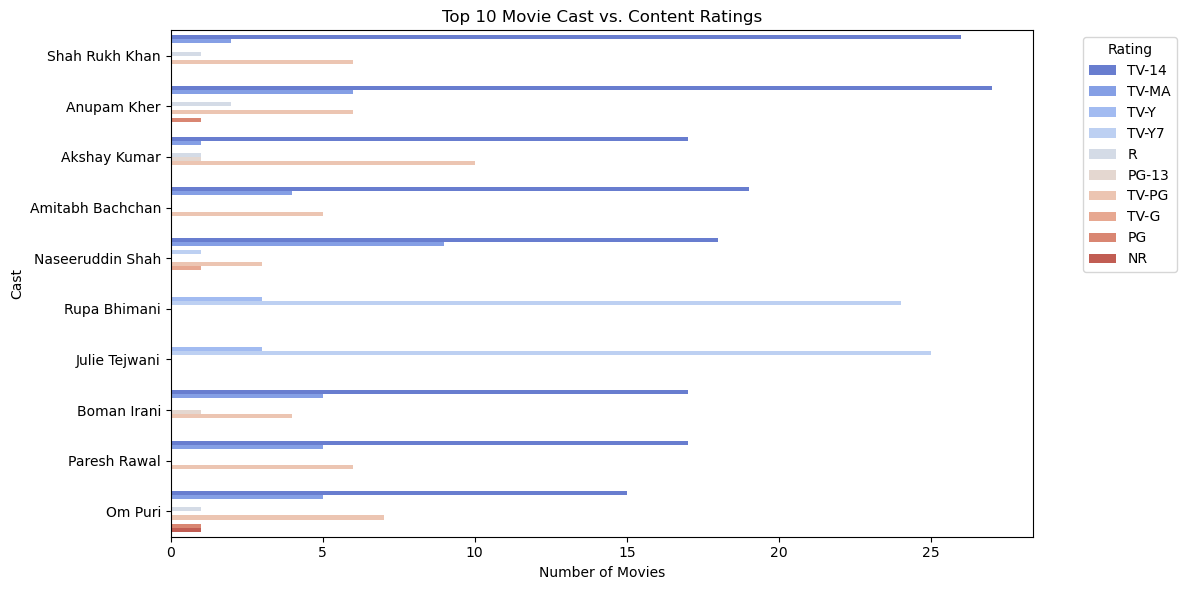

In [86]:
# --- Plot for Movies ---
plt.figure(figsize=(12, 6))
sns.countplot(data=movie_cast_filtered, y='cast', hue='rating', palette='coolwarm')
plt.title("Top 10 Movie Cast vs. Content Ratings")
plt.xlabel("Number of Movies")
plt.ylabel("Cast")
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



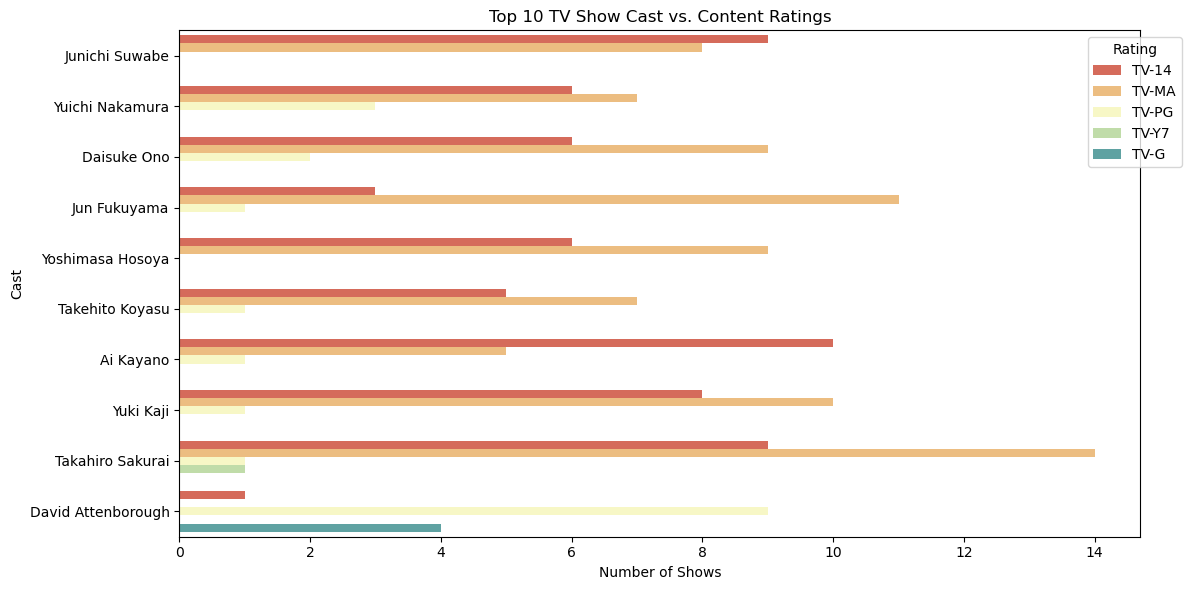

In [87]:
# --- Plot for TV Shows ---
plt.figure(figsize=(12, 6))
sns.countplot(data=show_cast_filtered, y='cast', hue='rating', palette='Spectral')
plt.title("Top 10 TV Show Cast vs. Content Ratings")
plt.xlabel("Number of Shows")
plt.ylabel("Cast")
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

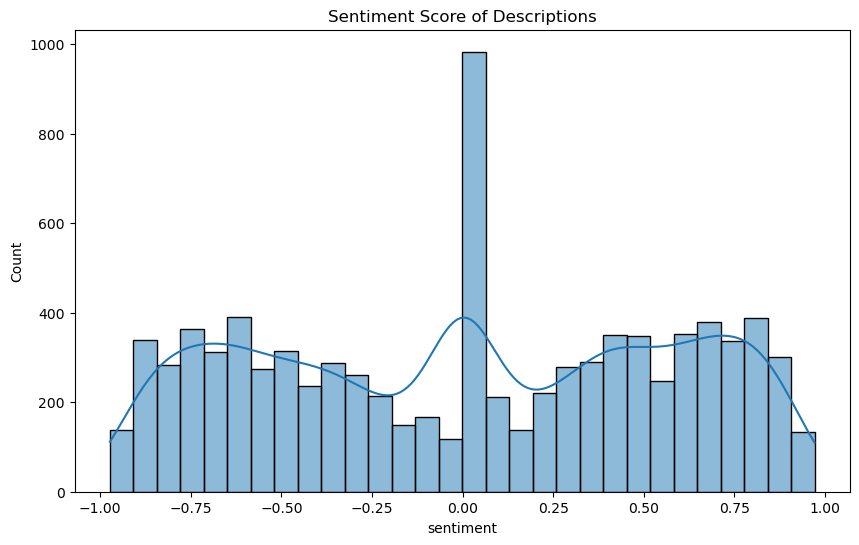

In [57]:
sia = SentimentIntensityAnalyzer()
df['description'] = df['description'].fillna("")
df['sentiment'] = df['description'].apply(lambda x: sia.polarity_scores(x)['compound'])

plt.figure(figsize=(10,6))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title("Sentiment Score of Descriptions")
plt.show()

In [58]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['description'])
nmf = NMF(n_components=5, random_state=42)
nmf_features = nmf.fit_transform(tfidf_matrix)

terms = tfidf_vectorizer.get_feature_names_out()
for idx, topic in enumerate(nmf.components_):
    print(f"\nTopic #{idx + 1}:")
    print(", ".join([terms[i] for i in topic.argsort()[-10:]]))


Topic #1:
finds, daughter, old, mother, son, father, family, woman, man, young

Topic #2:
ii, lives, stories, history, explores, war, follows, series, documentary, world

Topic #3:
best, year, finds, old, help, home, city, york, friends, new

Topic #4:
comedian, takes, career, comedy, real, special, comic, stand, love, life

Topic #5:
romance, best, college, girl, teacher, teen, students, student, high, school


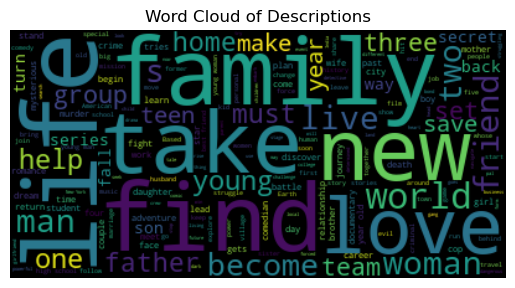

In [59]:
# Word Cloud
wordcloud = WordCloud(background_color='black').generate(' '.join(df['description']))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Descriptions")
plt.show()


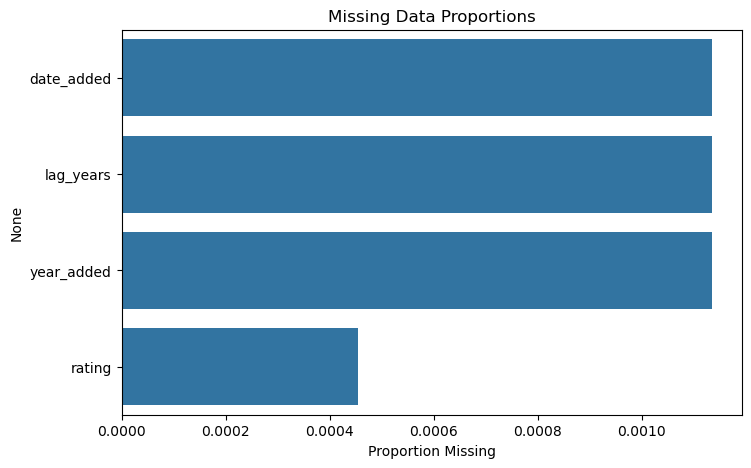

In [60]:
# === 8. Missing Data Patterns ===
missing_summary = df.isnull().mean().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

plt.figure(figsize=(8,5))
sns.barplot(x=missing_summary.values, y=missing_summary.index)
plt.title("Missing Data Proportions")
plt.xlabel("Proportion Missing")
plt.show()

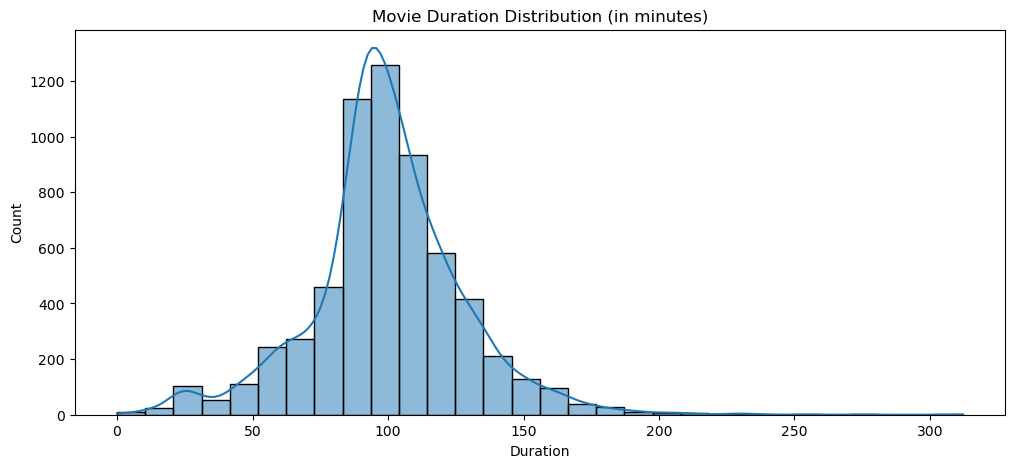

In [61]:
plt.figure(figsize=(12,5))
sns.histplot(df[df['type'] == 'Movie']['duration_int'].dropna(), bins=30, kde=True)
plt.title("Movie Duration Distribution (in minutes)")
plt.xlabel("Duration")
plt.show()

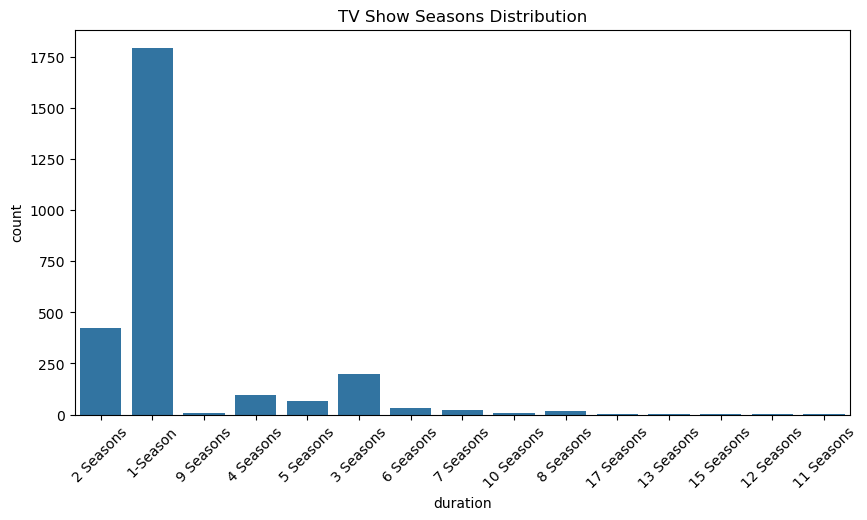

In [62]:
plt.figure(figsize=(10,5))
sns.countplot(x='duration', data=df[df['type'] == 'TV Show'].replace("1 Season", "1-Season"))
plt.title("TV Show Seasons Distribution")
plt.xticks(rotation=45)
plt.show()

In [63]:
df['genre_str'] = df['genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)
rec_vectorizer = TfidfVectorizer()
rec_matrix = rec_vectorizer.fit_transform(df['genre_str'].fillna(""))

print(f"Recommendation Matrix Shape (TF-IDF of Genres): {rec_matrix.shape}")

Recommendation Matrix Shape (TF-IDF of Genres): (8807, 45)


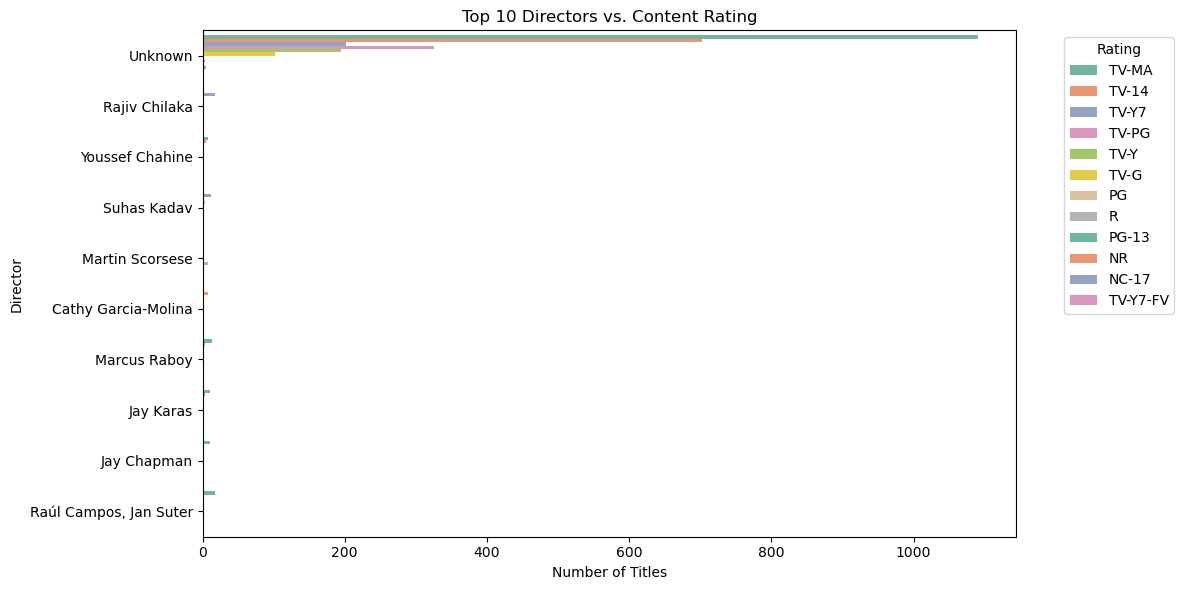